Цель: Научиться применять методы предобработки данных на реальном датасете, оценивать их влияние на качество модели и понимать важность каждого этапа.

Дтасет Bank Marketing Dataset

Ссылка для примера: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

Целевая переменная: deposit (будет ли клиент открывать депозит).



**Важное условие:** С самого начала разделите исходные данные на обучающую (train) и тестовую (test) выборки в соотношении 80/20. Используйте параметр random_state=42 для воспроизводимости. Все этапы предобработки (заполнение пропусков, кодирование, масштабирование, PCA) должны настраиваться/обучаться ТОЛЬКО на обучающей выборке, а затем применяться к тестовой. Это критически важно для корректной оценки. За основную модель возьмите Random Forest Classifier

1. Базовый анализ (1 балл)

- Загрузите данные, разделите на train/test

- Проведите разведочный анализ данных, посмотрите распределение целевой переменной

- Обучите модель на числовых признаках без обработки (baseline) и на тестовой выборке оцените accuracy


In [45]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(path, file), sep=';')
        print(f"Загружен файл: {file}")
        break

Using Colab cache for faster access to the 'bank-marketing' dataset.
Загружен файл: bank-additional-full.csv


In [46]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [47]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['y'])
X_train, X_test, y_train, y_test = train_test_split(X, df['y'], random_state=42, test_size=0.2, stratify=df['y'])
print(X_train.shape)
print(X_test.shape)

(32950, 20)
(8238, 20)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

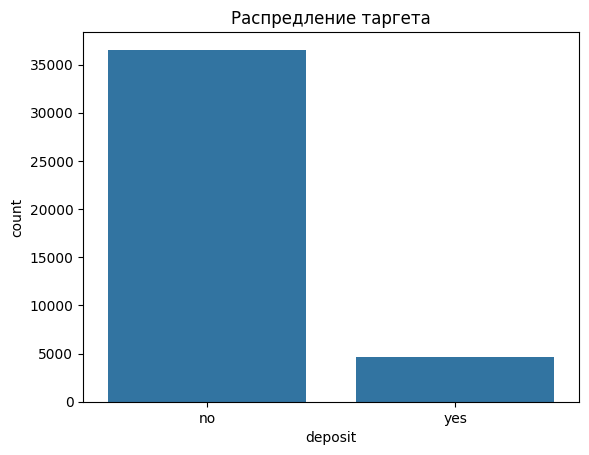

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="y")
plt.title("Распредление таргета")
plt.xlabel("deposit")
plt.ylabel("count")
plt.show()

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

num_cols = X.select_dtypes(include=["int64", "float64"]).columns

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train[num_cols], y_train)
y_pred = model.predict(X_test[num_cols])
acc_base = accuracy_score(y_test, y_pred)
print(acc_base)

0.9174556931294003


2. Обработка пропусков (2 балла)

- Найдите и заполните пропуски в train (2 способами):
  - Удаление строк с пропусками
  - Замена пропусков на медиану (для числовых) или моду (для категориальных).

- Обучите модель на данных без пропусков и на тестовой выборке оцените accuracy

In [51]:
import numpy as np

X_train.isna().sum()
(X_train == "unknown").sum()
X_train = X_train.replace("unknown", np.nan)
X_train.isna().sum()

,0
age,0
job,265
marital,65
education,1397
default,6940
housing,796
loan,796
contact,0
month,0
day_of_week,0


In [52]:

for col in num_cols:
  X_train[col] = X_train[col].fillna(X_train[col].median())

X_train.isna().sum()

,0
age,0
job,265
marital,65
education,1397
default,6940
housing,796
loan,796
contact,0
month,0
day_of_week,0


In [53]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train[num_cols], y_train)
y_pred = model.predict(X_test[num_cols])
acc_base = accuracy_score(y_test, y_pred)
print(acc_base)

0.9174556931294003


Пометочка: очевидно, что acc не поменялось, потому что Nan изначально не было, только unknown, а это уже относится к категориальным признакам

3. Кодирование категориальных признаков (2 балла)
- Используй данные полученные 2  методом и далее во всех задачах

- Примените Label Encoding и One-Hot Encoding

- Обучите модель с закодированными признаками и на тестовой выборке оцените accuracy



In [54]:
X_train = X_train.replace({"no": 0, "yes": 1, "unknown": -1})
X_train.head()

/tmp/ipython-input-205136661.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.replace({"no": 0, "yes": 1, "unknown": -1})


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
25611,49,blue-collar,married,basic.9y,NaN,0.0,0.0,cellular,nov,wed,227,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8
26010,37,entrepreneur,married,university.degree,0.0,0.0,0.0,telephone,nov,wed,202,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8
40194,78,retired,married,basic.4y,0.0,0.0,0.0,cellular,jul,mon,1148,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6
297,36,admin.,married,university.degree,0.0,1.0,0.0,telephone,may,mon,120,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
36344,59,retired,divorced,university.degree,0.0,0.0,0.0,cellular,jun,tue,368,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2


In [55]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32950 entries, 25611 to 10747
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32685 non-null  object 
 2   marital         32885 non-null  object 
 3   education       31553 non-null  object 
 4   default         26010 non-null  float64
 5   housing         32154 non-null  float64
 6   loan            32154 non-null  float64
 7   contact         32950 non-null  object 
 8   month           32950 non-null  object 
 9   day_of_week     32950 non-null  object 
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  object 
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  float64
 17  cons.conf.idx   32950 non-null  

In [56]:
day_order = ["mon", "tue", "wed", "thu", "fri"]
X_train["day_of_week"] = X_train["day_of_week"].replace(day_order, range(len(day_order)))

month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
X_train["month"] = X_train["month"].replace(month_order, range(len(month_order)))

edu_order = ["illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree"]
X_train["education"] = X_train["education"].replace(edu_order, range(len(edu_order)))

poutcome_order = ["failure", "nonexistent", "success"]
X_train["poutcome"] = X_train["poutcome"].replace(poutcome_order, range(len(poutcome_order)))

/tmp/ipython-input-3990298989.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train["day_of_week"] = X_train["day_of_week"].replace(day_order, range(len(day_order)))
/tmp/ipython-input-3990298989.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train["month"] = X_train["month"].replace(month_order, range(len(month_order)))
/tmp/ipython-input-3990298989.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_ob

In [70]:
X_train = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=int)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 32950 entries, 25611 to 10747
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                32950 non-null  int64  
 1   education          31553 non-null  float64
 2   default            26010 non-null  float64
 3   housing            32154 non-null  float64
 4   loan               32154 non-null  float64
 5   month              32950 non-null  int64  
 6   day_of_week        32950 non-null  int64  
 7   duration           32950 non-null  int64  
 8   campaign           32950 non-null  int64  
 9   pdays              32950 non-null  int64  
 10  previous           32950 non-null  int64  
 11  poutcome           32950 non-null  int64  
 12  emp.var.rate       32950 non-null  float64
 13  cons.price.idx     32950 non-null  float64
 14  cons.conf.idx      32950 non-null  float64
 15  euribor3m          32950 non-null  float64
 16  nr.employed        3295

In [71]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_enc = accuracy_score(y_test, y_pred)
print(acc_enc)

0.9186695799951444


а у меня были большие надежды на это(

4. Обработка выбросов (2 балла )
- Визуализируйте выбросы с помощью boxplot для числовых признаков.

- Примените метод IQR для обнаружения и обработки выбросов .

- Обучите модель на данных без выбросов и на тестовой выборке оцените accuracy


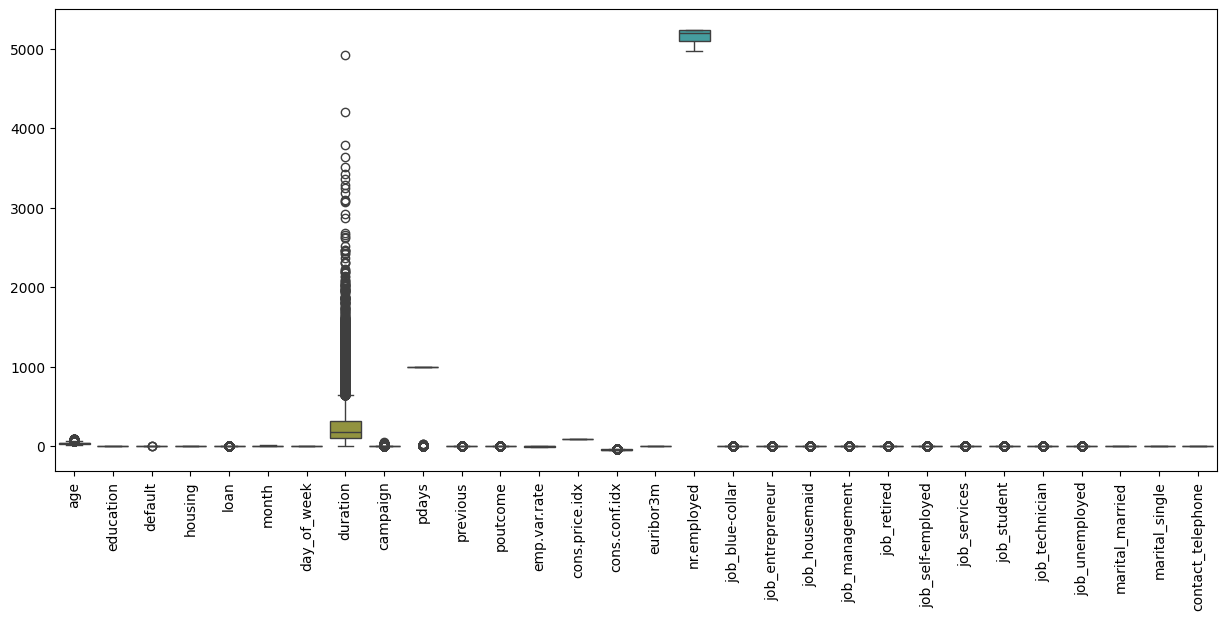

In [72]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.show()

In [74]:
for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)


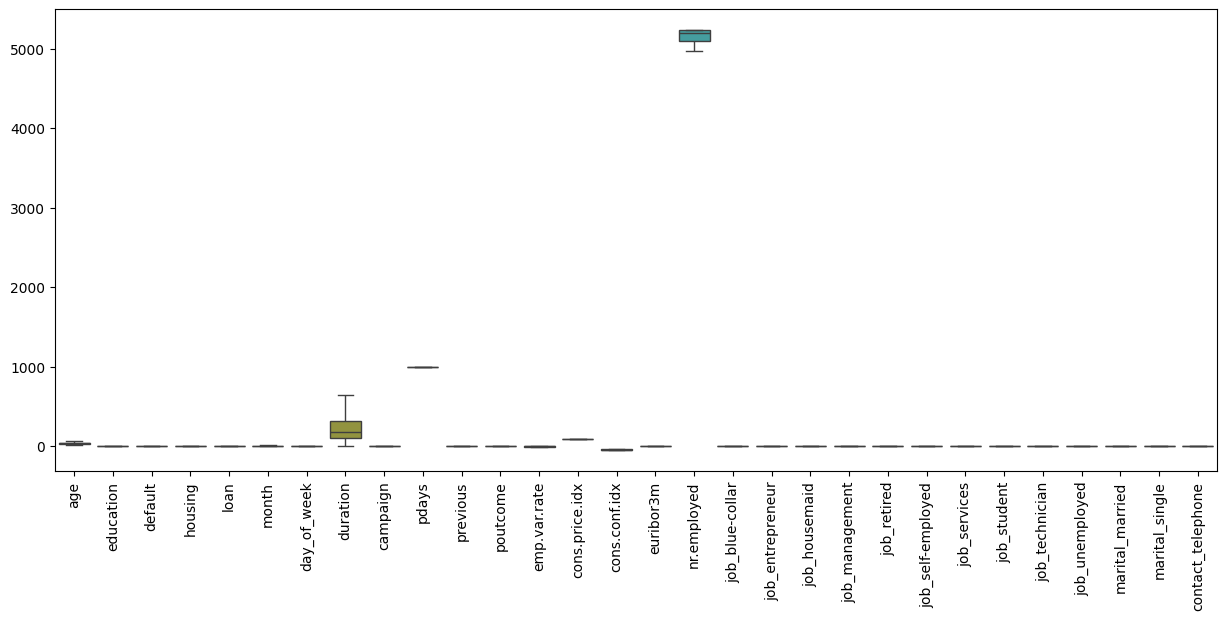

In [75]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.show()

In [76]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_iqr = accuracy_score(y_test, y_pred)
print(acc_iqr)

0.9127215343529983


почему стало хуже ну неееет((((

5. Масштабирование признаков (2 балла)

- Примените StandardScaler или MinMaxScaler только к train выборке

- Обучите модель на данных с масштабированными признаками и на тестовой выборке оцените accuracy


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

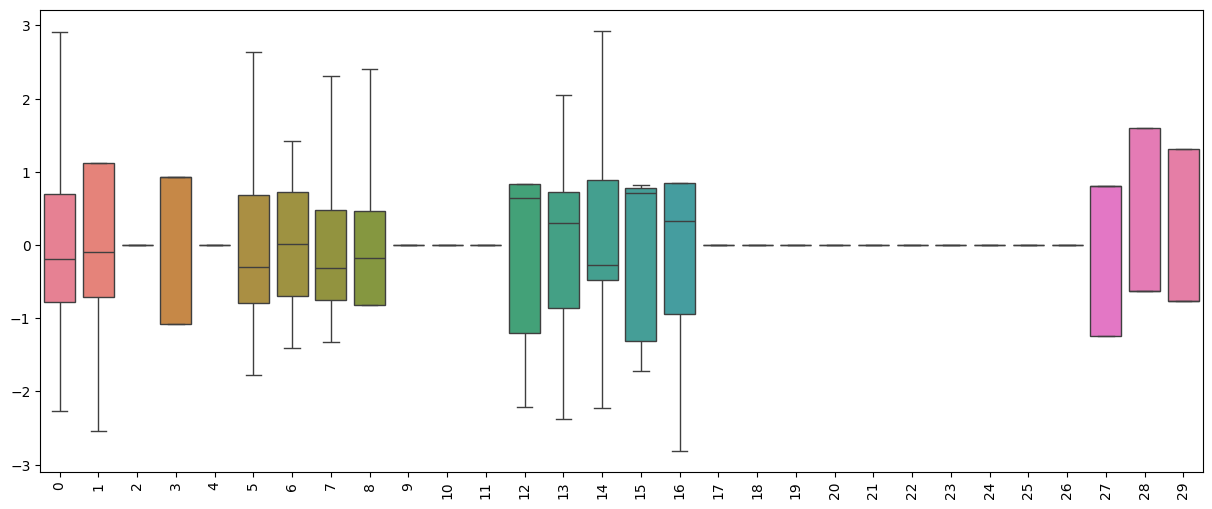

In [79]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.show()

In [80]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_scal = accuracy_score(y_test, y_pred)
print(acc_scal)

0.9124787569798495


6. Итоги (1 балл)

- Сравните модели и создайте таблицу с accuracy всех моделей.
- Сделайте выводы

In [81]:
table_res = {'Model': ['Baseline', 'Обработка пропусков', 'L/OH encoding', 'Обработка выбросов', 'Scaler'],
             'Accuracy': [acc_base, acc_base, acc_enc, acc_iqr, acc_scal]}
table_res = pd.DataFrame(table_res)
table_res

,Model,Accuracy
0,Baseline,0.917456
1,Обработка пропусков,0.917456
2,L/OH encoding,0.918670
3,Обработка выбросов,0.912722
4,Scaler,0.912479


Я ожидала гораздо большего увеличения acc(  
То, что с 3 пункта с 0.918 понизилось до 0.912 это вообще для меня непонятно, может быть что-то было сделано не так, но я проверяла.  
А теперь официальный отчет:  
Label encoding и One-hot encoding подняли acc больше всего, это хорошая практика. А вот при обработке выбросов видимо были отсечены важные данные. Можно  еще попробовать по другому переделать энкодинг и замены. В итоге acc уменьшилось по сравнению с baseline, такого, кнечно, не должно было произойти, но все бывает.